In [1]:
%load_ext autoreload
%autoreload 2

from IPython.core.display import display, HTML
display(HTML("<style>.container { width:95% !important; }</style>"))

# import rdkit
from rdkit.Chem import Draw
from rdkit.Chem import PandasTools

import warnings
warnings.filterwarnings("ignore")

import sys
# sys.executable

# Data

In [2]:
import os

from rdkit import Chem
from IPython.display import HTML
from rdkit.Chem import PandasTools
import pandas as pd

def displaydf(df):
    return HTML(df.to_html(notebook=True))

ddir = 'data/'
df = pd.read_csv(os.path.join(ddir,'partial_data.csv'))
df.columns = ['smiles']
display(df)

PandasTools.AddMoleculeColumnToFrame(df,'smiles','molecule',includeFingerprints=False)
# displaydf(df.head(2))

,smiles
0,c1c(N2C(=O)N3CC(N(CC)Cc4cccc(-c5ccc(C#N)cc5)c4...
1,c1(S(=O)(=O)N(CC)CC)c(C)ccc(C(=O)Nc2ccc(Cl)cn2)c1
2,c1c2oc(-c3cc(O)c(O)c(O)c3)c(OC3C(O)C(O)C(O)C(C...
3,C(c1nc(-c2cccc(NC(=O)c3ccc(C)s3)c2)oc1C)NC(=O)...
4,N(c1ccccc1)C(=O)c1cn(-c2ccccc2)nc1-c1ccc(Cl)cc1
...,...
995,CN(CC(=O)Nc1ccc(Cl)c(c1)C(F)(F)F)C(=O)CC1Sc2cc...
996,CCOc1nc2ccc(OCCC3CCN(CC3)c3ccc(C)nn3)cc2s1
997,CN(C1CS(=O)(=O)CC1)C(COc1ccccc1)=O
998,CCCC(=O)Nc1n[nH]c2cc(Cl)c(cc12)-c1ccc(CC)cc1


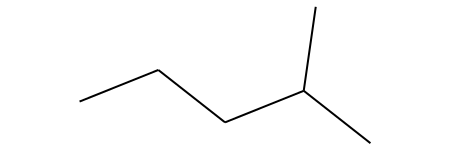

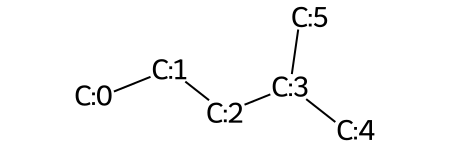

In [4]:
from rdkit import Chem
from rdkit.Chem import Draw
from rdkit.Chem.Draw import IPythonConsole
IPythonConsole.ipython_useSVG = True

import EvoMol_molgraph as evomol
from rdkit_utils import mol_with_atom_index, copy_rwmol, update_mol_rep, get_rwmol

smiles = df.smiles[6] #'CCC(C)(C)C'
smiles = 'CCCC(C)C'
mol = Chem.MolFromSmiles(smiles)
rwmol = get_rwmol(mol)

# molgraph = evomol.MolGraph(rwmol)
molgraph = get_rwmol(mol)
display(molgraph)
display(mol_with_atom_index(mol))

# <font color=blue> First goal: "Add atom"

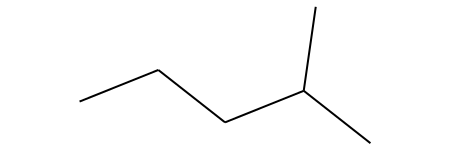

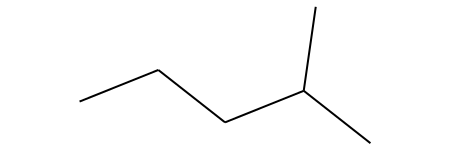

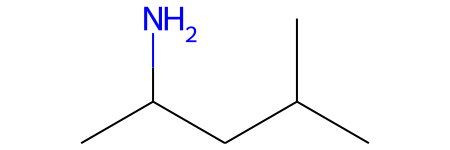

In [7]:
from rdkit.Chem.rdchem import RWMol, Atom, Bond, BondType
from rdkit_utils import mol_with_atom_index, copy_rwmol, update_mol_rep, get_rwmol

def add_atom_to_mol(molgraph, atom_type, to_aidx): 
    """
    :param molgraph: RWMol object
    :param atom_type: str 
    :param to_aidx: int, which index of molecule to add new atom
    :return: new graph after atom addition
    """
    molgraph_new = copy_rwmol(molgraph)
    
    # add atom to mol object
    atom = Atom(atom_type)
    atom.SetBoolProp("mutability", True)    
    molgraph_new.AddAtom(atom)
    
    # create bond from new atom to source molecule
    molgraph_new.AddBond(molgraph_new.GetNumAtoms() - 1, to_aidx, BondType.SINGLE)
    
    update_mol_rep(molgraph_new)
    return molgraph_new

smiles = 'CCCC(C)C'
molgraph = get_rwmol( Chem.MolFromSmiles(smiles) )

display(molgraph)
molgraph_new = add_atom_to_mol(molgraph, 'N', 1)
display(molgraph, molgraph_new)

In [ ]:
import random
import numpy as np

random.seed(666)

In [ ]:
def add_bond(self, from_atom, to_atom, update_rep=True):


    # Extracting current bond between given atoms
    curr_bond = self.mol_graph.GetBondBetweenAtoms(from_at, to_at)

    if curr_bond is None:
        self.mol_graph.AddBond(from_at, to_at, BondType.SINGLE)
        # print("Adding None -> Single bond between atoms of idx " + str(from_at) + " and " + str(to_at))
    elif Bond.GetBondType(curr_bond) == BondType.SINGLE:
        # print("Adding Single -> Double bond between atoms of idx " + str(from_at) + " and " + str(to_at))
        curr_bond.SetBondType(BondType.DOUBLE)
    elif Bond.GetBondType(curr_bond) == BondType.DOUBLE:
        # print("Adding Double -> Triple bond between atoms of idx " + str(from_at) + " and " + str(to_at))
        curr_bond.SetBondType(BondType.TRIPLE)

    else:
        print("Unknown bond type : " + self.to_smiles())
        raise Exception("Unknown bond type : " + self.to_smiles())

    if update_repr:
        # Updating internal representation
        self.evomol.update_mol_representation()

# <font color=blue> NOTES:
- Use `add_bond` later for bond editting !!! (line 205 of EvoMol_molgraph.py)
- In EvoMol's "actionspace" ... `action_id` = index on atoms !!!!

In [ ]:
def randomly_add_atom(graph,atom_type='O'):
    
    idc = np.arange(graph.mol_graph.GetNumAtoms())
    random.shuffle(idc)
    for i in idc:
        try:
            graph.add_atom(atom_type)
        except Exception as e:
            continue
    else:
        return None
    
    return graph

graph = molgraph.MolGraph(rwmol)
randomly_add_atom(graph)